<a href="https://colab.research.google.com/github/mrstarnge09/EV-Battery-SoH-Prediction/blob/main/EV_Battery_State_of_Health_(SoH)_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   total_distance_km  average_trip_speed_kmph  ambient_temperature_C  \
0           15607.06                    34.95                  35.55   
1           38077.86                    33.32                  16.46   
2           29547.76                    27.05                  22.13   
3           24347.68                    44.29                  33.21   
4            7084.73                    39.06                  26.87   

   trip_duration_min  charging_cycles  fast_charging_ratio_%  \
0              61.05              270                  20.82   
1              46.74              685                  51.85   
2              87.16              533                  34.93   
3              27.52              438                  42.09   
4              57.03              113                   1.62   

   average_battery_temperature_C  battery_health_%  
0                          37.86             75.37  
1                          26.59             45.00  
2                      

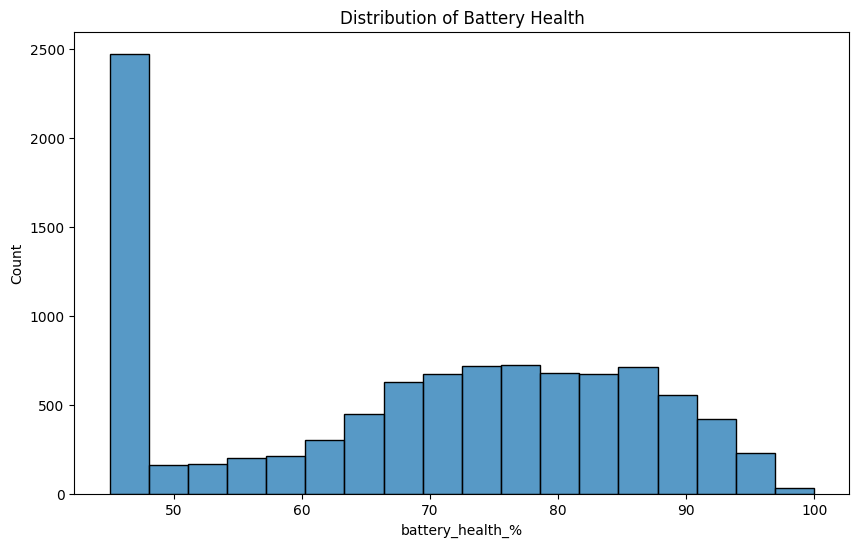

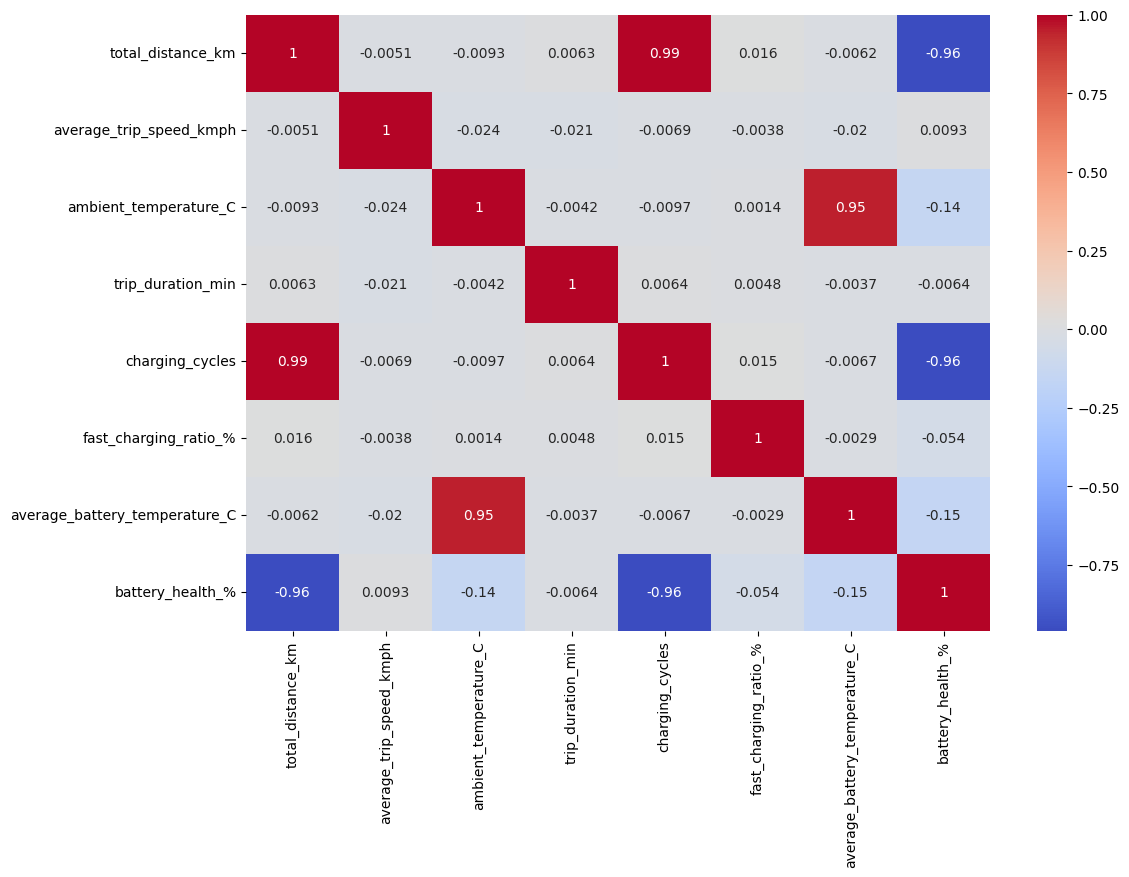

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv('ev.csv')

# 3. Basic Checks
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

# 4. Check for missing values
print(df.isnull().sum())

# 5. Visualize important columns
# Example plots you should make:
plt.figure(figsize=(10,6))
sns.histplot(df['battery_health_%'])   # or 'Capacity' or 'SoH'
plt.title('Distribution of Battery Health')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Assuming 'battery_health_%' is your target column
X = df.drop('battery_health_%', axis=1)   # Change column name as per your dataset
y = df['battery_health_%']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
evaluate_model(y_test, pred_lr, 'Linear Regression')


Linear Regression Results:
MAE: 2.932317861761383
RMSE: 3.70001439300735
R2 Score: 0.9501846216141315


In [5]:
evaluate_model(y_test, pred_rf, 'Random Forest')


Random Forest Results:
MAE: 0.9888676000000001
RMSE: 1.4095338771771329
R2 Score: 0.9927705103030381


In [6]:
evaluate_model(y_test, pred_xgb, 'XGBoost')


XGBoost Results:
MAE: 1.0763452011871337
RMSE: 1.5256977428603429
R2 Score: 0.9915298009968455


In [8]:
# ====================== COMPLETE CODE ======================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make sure these variables exist (from previous cells)
print("Checking shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

# Train the models
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)

xgb = XGBRegressor(random_state=42, n_estimators=100)
xgb.fit(X_train_scaled, y_train)
pred_xgb = xgb.predict(X_test_scaled)

# Evaluation Function
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name} Results:")
    print(f"MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE : {mean_squared_error(y_true, y_pred)**0.5:.4f}")
    print(f"R²   : {r2_score(y_true, y_pred):.4f}")

# Call the function
evaluate_model(y_test, pred_lr, "Linear Regression")
evaluate_model(y_test, pred_rf, "Random Forest")
evaluate_model(y_test, pred_xgb, "XGBoost")

Checking shapes:
X_train_scaled: (8000, 7)
X_test_scaled : (2000, 7)
y_train       : (8000,)
y_test        : (2000,)

🔹 Linear Regression Results:
MAE  : 2.9323
RMSE : 3.7000
R²   : 0.9502

🔹 Random Forest Results:
MAE  : 0.9889
RMSE : 1.4095
R²   : 0.9928

🔹 XGBoost Results:
MAE  : 1.0763
RMSE : 1.5257
R²   : 0.9915


=== Loading Dataset ===
Dataset Shape: (10000, 8)

First 5 rows:
   total_distance_km  average_trip_speed_kmph  ambient_temperature_C  \
0           15607.06                    34.95                  35.55   
1           38077.86                    33.32                  16.46   
2           29547.76                    27.05                  22.13   
3           24347.68                    44.29                  33.21   
4            7084.73                    39.06                  26.87   

   trip_duration_min  charging_cycles  fast_charging_ratio_%  \
0              61.05              270                  20.82   
1              46.74              685                  51.85   
2              87.16              533                  34.93   
3              27.52              438                  42.09   
4              57.03              113                   1.62   

   average_battery_temperature_C  battery_health_%  
0                          37.86             75.37  
1          

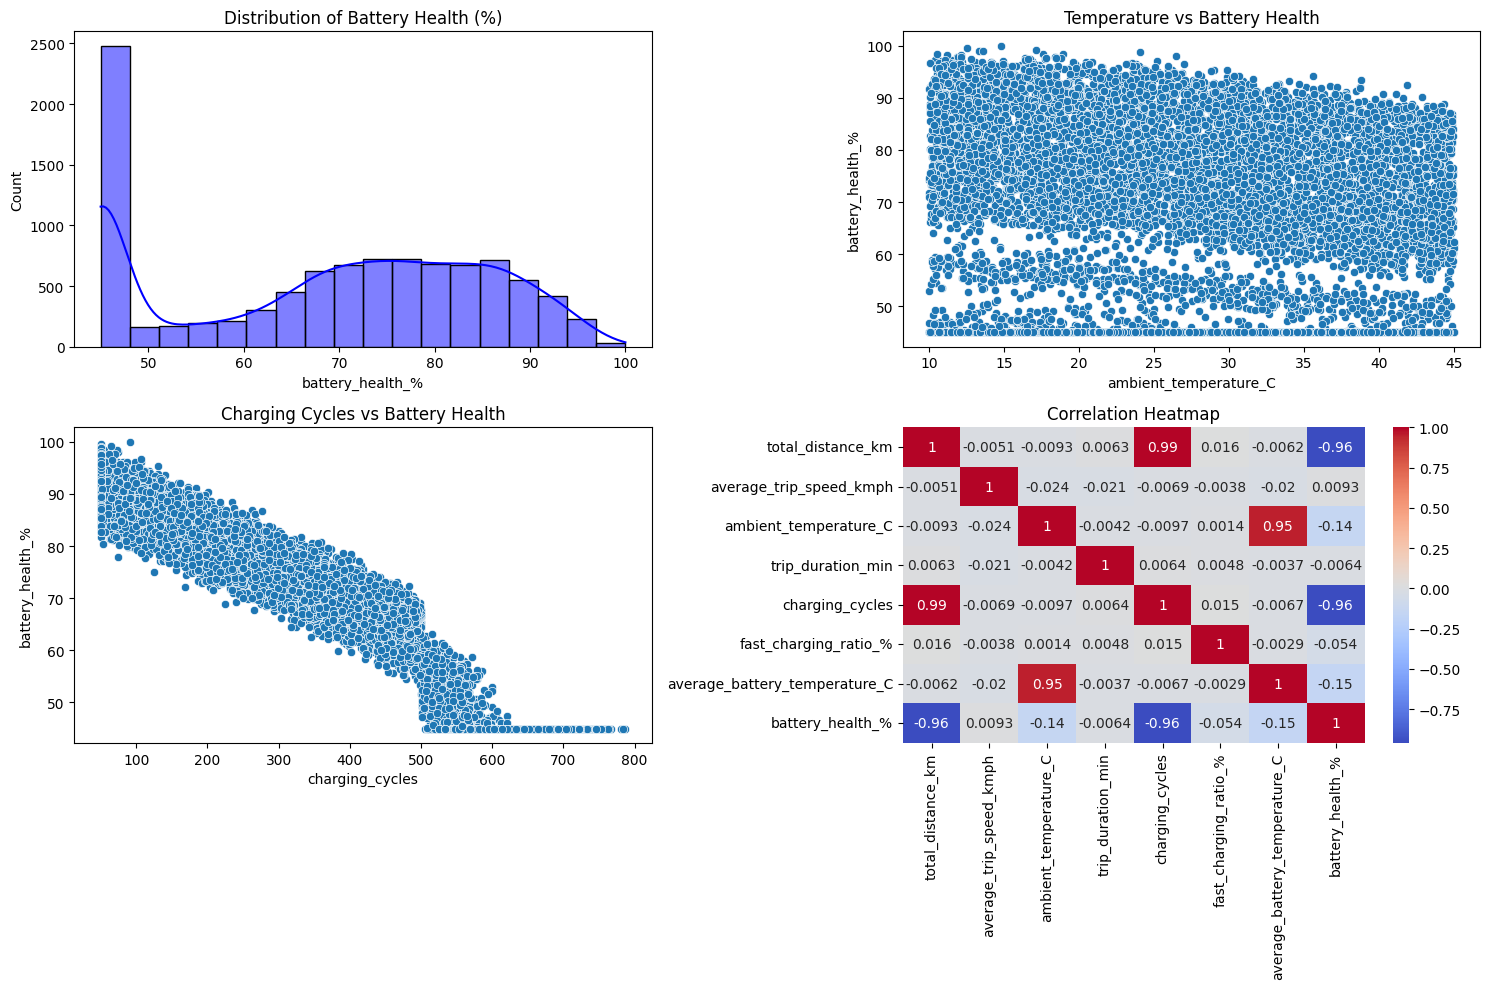

Data Preprocessing Completed!
=== Model Performance Comparison ===

🔹 Linear Regression Results:
MAE  : 2.9323
RMSE : 3.7000
R²   : 0.9502

🔹 Random Forest Results:
MAE  : 0.9889
RMSE : 1.4095
R²   : 0.9928

🔹 XGBoost Results:
MAE  : 1.0763
RMSE : 1.5257
R²   : 0.9915


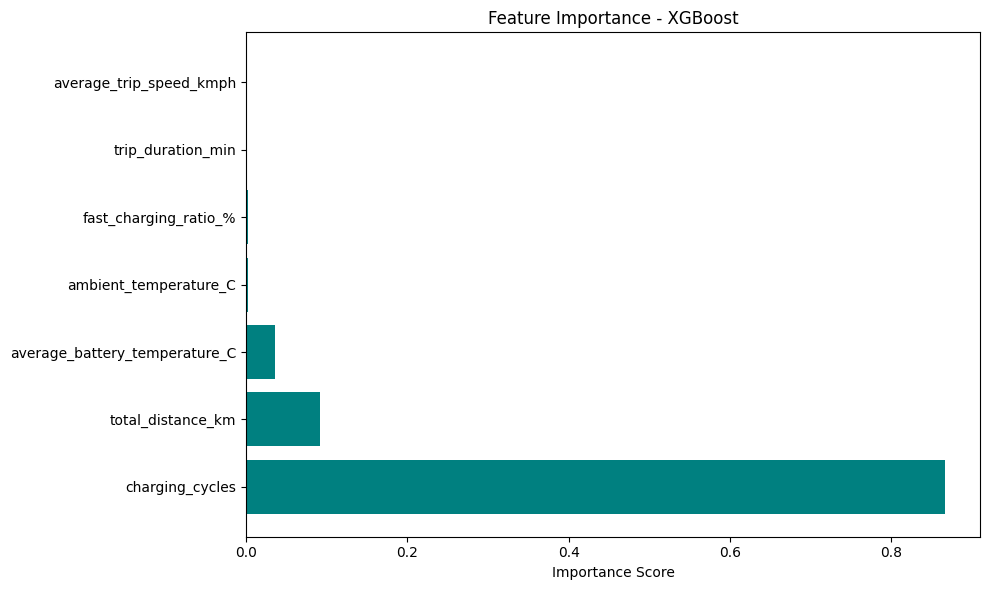


Final Model Comparison:
               Model     MAE    RMSE  R2 Score
0  Linear Regression  2.9323  3.7000    0.9502
1      Random Forest  0.9889  1.4095    0.9928
2            XGBoost  1.0763  1.5257    0.9915

✅ Best Model (XGBoost) and Scaler Saved Successfully!


In [10]:
# =====================================================
# EV BATTERY STATE OF HEALTH (SoH) PREDICTION
# Full Code - Week 1 to Week 3
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ====================== WEEK 1: LOAD & EDA ======================

print("=== Loading Dataset ===")
# Change the filename as per your downloaded file
df = pd.read_csv('ev.csv')   # ← Update this name

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# ====================== VISUALIZATIONS ======================

plt.figure(figsize=(15, 10))

# Distribution of Battery Health
plt.subplot(2, 2, 1)
sns.histplot(df['battery_health_%'], kde=True, color='blue')
plt.title('Distribution of Battery Health (%)')

# Temperature vs Battery Health
plt.subplot(2, 2, 2)
sns.scatterplot(x='ambient_temperature_C', y='battery_health_%', data=df)
plt.title('Temperature vs Battery Health')

# Charging Cycles vs Battery Health
plt.subplot(2, 2, 3)
sns.scatterplot(x='charging_cycles', y='battery_health_%', data=df)
plt.title('Charging Cycles vs Battery Health')

# Correlation Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# ====================== WEEK 2: PREPROCESSING & MODELING ======================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features and target
X = df.drop('battery_health_%', axis=1)
y = df['battery_health_%']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Completed!")

# ====================== TRAIN MODELS ======================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)

# XGBoost
xgb = XGBRegressor(random_state=42, n_estimators=100)
xgb.fit(X_train_scaled, y_train)
pred_xgb = xgb.predict(X_test_scaled)

# ====================== EVALUATION ======================

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n🔹 {model_name} Results:")
    print(f"MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE : {mean_squared_error(y_true, y_pred)**0.5:.4f}")
    print(f"R²   : {r2_score(y_true, y_pred):.4f}")

print("=== Model Performance Comparison ===")
evaluate_model(y_test, pred_lr, "Linear Regression")
evaluate_model(y_test, pred_rf, "Random Forest")
evaluate_model(y_test, pred_xgb, "XGBoost")

# ====================== WEEK 3: FEATURE IMPORTANCE ======================

plt.figure(figsize=(10, 6))
feature_importance = xgb.feature_importances_
features = X.columns

indices = feature_importance.argsort()[::-1]
plt.barh(features[indices], feature_importance[indices], color='teal')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ====================== MODEL COMPARISON TABLE ======================

results = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mean_absolute_error(y_test, pred_lr),
            mean_absolute_error(y_test, pred_rf),
            mean_absolute_error(y_test, pred_xgb)],
    'RMSE': [mean_squared_error(y_test, pred_lr)**0.5,
             mean_squared_error(y_test, pred_rf)**0.5,
             mean_squared_error(y_test, pred_xgb)**0.5],
    'R2 Score': [r2_score(y_test, pred_lr),
                 r2_score(y_test, pred_rf),
                 r2_score(y_test, pred_xgb)]
}

comparison_df = pd.DataFrame(results)
print("\nFinal Model Comparison:")
print(comparison_df.round(4))

# ====================== SAVE MODEL ======================

import joblib

joblib.dump(xgb, 'ev_battery_soh_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\n✅ Best Model (XGBoost) and Scaler Saved Successfully!")